# Data preprocessing

In [1]:
from utils.data_utils import *
from utils.preprocessing_utils import *
from PCN import *

categorical_features = [
    "L4_SRC_PORT",           
    "L4_DST_PORT",
    "PROTOCOL",              
    "L7_PROTO",
    "TCP_FLAGS",             
    "CLIENT_TCP_FLAGS",
    "SERVER_TCP_FLAGS",
    "ICMP_TYPE",             
    "ICMP_IPV4_TYPE",
    "DNS_QUERY_ID",          
    "DNS_QUERY_TYPE",        
    "FTP_COMMAND_RET_CODE"   
]

numerical_features = [
    "IN_BYTES",
    "OUT_BYTES",
    "IN_PKTS",
    "OUT_PKTS",
    "FLOW_DURATION_MILLISECONDS",
    "DURATION_IN",
    "DURATION_OUT",
    "MIN_TTL",                   
    "MAX_TTL",
    "LONGEST_FLOW_PKT",
    "SHORTEST_FLOW_PKT",
    "MIN_IP_PKT_LEN",
    "MAX_IP_PKT_LEN",
    "SRC_TO_DST_SECOND_BYTES",
    "DST_TO_SRC_SECOND_BYTES",
    "RETRANSMITTED_IN_BYTES",
    "RETRANSMITTED_IN_PKTS",
    "RETRANSMITTED_OUT_BYTES",
    "RETRANSMITTED_OUT_PKTS",
    "SRC_TO_DST_AVG_THROUGHPUT",
    "DST_TO_SRC_AVG_THROUGHPUT",
    "NUM_PKTS_UP_TO_128_BYTES",
    "NUM_PKTS_128_TO_256_BYTES",
    "NUM_PKTS_256_TO_512_BYTES",
    "NUM_PKTS_512_TO_1024_BYTES",
    "NUM_PKTS_1024_TO_1514_BYTES",
    "TCP_WIN_MAX_IN",            
    "TCP_WIN_MAX_OUT",
    "DNS_TTL_ANSWER"             
    ]

T_infer = 100

X, y = load_dataset("archive/NF-UNSW-NB15-v2.csv")

In [2]:
removed = False
if not removed:
    X = remove_ip_fields(X)
    removed = True #we can re-run the cell
X_train, X_test, y_train, y_test = split_dataset(X, y, test_size=0.2)
X_train, y_ssl = create_ssl_dataset(X_train, y_train, label_ratio=0.99)

print(X_train.shape)
print(y_ssl.head())
print(y_ssl.value_counts())

(1912220, 41)
1987663    0
1380376    0
920516     0
1605761    0
328621     0
Name: Label, dtype: int64
Label
 0    1817816
 1      75282
-1      19122
Name: count, dtype: int64


In [3]:
X_train = cap_numerical_data(X_train, numerical_features)
X_test = cap_numerical_data(X_test, numerical_features)

X_train, X_test, min_max_scaler = min_max_log_norm(X_train, X_test, numerical_features)
X_train, X_test, categories_dict = keep_top_categorical_level(X_train, X_test, categorical_features, max_levels=32)
print(categories_dict)

X_train, X_test, one_hot_encoder = ordinal_encode_categorical(X_train, X_test, categorical_features)
print(X_train.head())

{'L4_SRC_PORT': ['0', '47439', '1043', '80', '21', '6881', '53', '5190', '25', '143', '22', '1024', '5060', '1035', '1114', '111', '1155', '2041', '1328', '1585', '1250', '1243', '1199', '1417', '1301', '1660', '1669', '1405', '1418', '1580', '1634'], 'L4_DST_PORT': ['21', '53', '80', '6881', '5190', '111', '25', '143', '22', '0', '179', '445', '520', '860', '514', '110', '1723', '8089', '3260', '135', '5060', '24160', '25885', '69', '3354', '8080', '3306', '52561', '61097', '7395', '19414'], 'PROTOCOL': ['6', '17', '1', '89', '2', '47', '77', '41', '103', '33', '55', '53', '132', '150', '196', '91', '110', '233', '20', '158', '155', '92', '8', '224', '102', '167', '114', '253', '109', '205', '160'], 'L7_PROTO': ['0.0', '1.0', '7.0', '3.0', '92.0', '4.0', '17.0', '13.0', '41.0', '127.0', '20.0', '131.7', '96.0', '139.0', '78.0', '2.0', '77.0', '50.0', '7.131', '112.0', '84.0', '100.0', '10.0', '5.0', '18.0', '131.0', '161.0', '111.0', '89.0', '79.0', '164.0'], 'TCP_FLAGS': ['27', '0', 

# Predictive Coding Network

In [4]:
from torch import float32
from torch.utils.data import DataLoader
from PCN.trainer import train_pcn_binary


from PCN.PCNetwork import PredictiveCodingNetwork

device = 'cuda'
pcn = PredictiveCodingNetwork([41, 512, 256, 128, 64, 32, 16])
X_tensor = torch.tensor(np.array(X_train), dtype=float32).to(device)
print("X tensor ok")
y_tensor = torch.tensor(np.array(y_ssl), dtype=float32).to(device)
print("y tensor ok")
print(X_train.shape)
print(y_ssl.shape)

train_loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=2048, shuffle=True)
print("trainloader")
train_pcn_binary(model=pcn, data_loader=train_loader, num_epochs=20, eta_infer=0.05, eta_learn=0.001, T_infer=T_infer, margin_attack=5000, device=device)
torch.save(pcn.state_dict(), 'pcn_model_weights_2.pth')

X tensor ok
y tensor ok
(1912220, 41)
(1912220,)
trainloader
training started


 86%|████████▋ | 807/934 [04:55<00:46,  2.73it/s]


KeyboardInterrupt: 

Inizio valutazione e calcolo delle energie. Potrebbe volerci qualche istante...


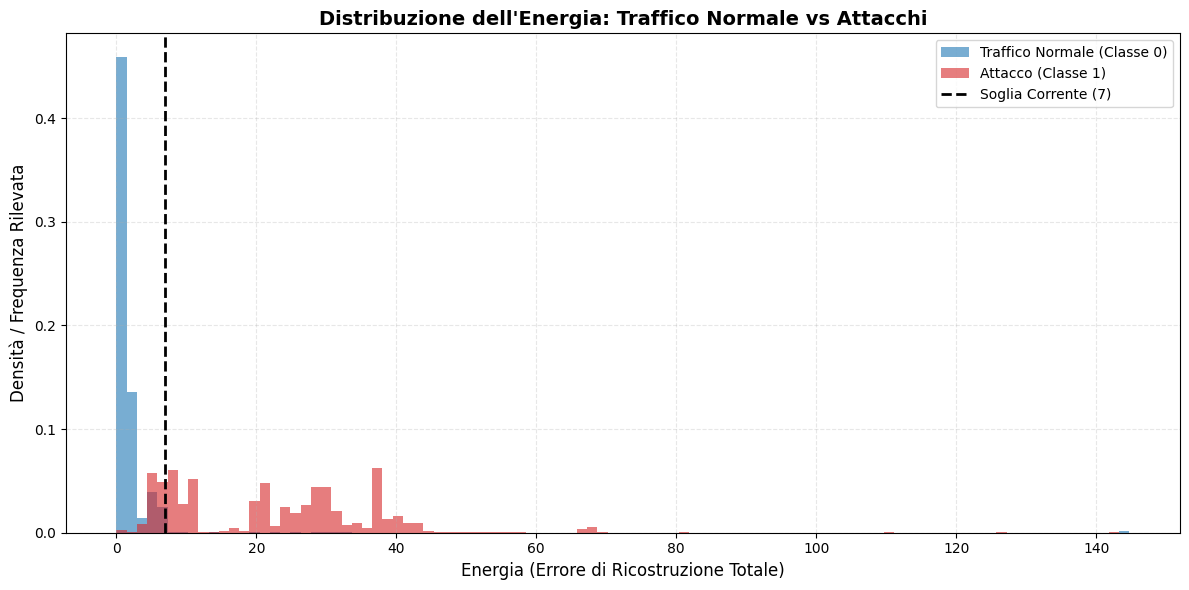


--- Risultati con Soglia Energia = 7 ---

Confusion Matrix:
[[452305   6739]
 [  2655  16356]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99    459044
         1.0       0.71      0.86      0.78     19011

    accuracy                           0.98    478055
   macro avg       0.85      0.92      0.88    478055
weighted avg       0.98      0.98      0.98    478055



(array([0.22968183, 0.05847684, 2.4453616 , ..., 0.17761151, 0.04497561,
        0.19072337], shape=(478055,), dtype=float32),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(478055,), dtype=float32))

In [ ]:
from utils.train_utils import  evaluate_pcn_anomaly
from PCN.PCNetwork import PredictiveCodingNetwork
device = 'cuda'

pcn_loaded = PredictiveCodingNetwork([41, 512, 256, 128, 64, 32, 16])
state_dict = torch.load('pcn_model_weights_2.pth', map_location=device)
pcn_loaded.load_state_dict(state_dict)
pcn_loaded.to(device)
X_test_tensor = torch.tensor(np.array(X_test), dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(np.array(y_test), dtype=torch.float32).view(-1, 1).to(device)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=2048, shuffle=False)
pcn_loaded.eval()

evaluate_pcn_anomaly(pcn_loaded, test_loader, T_infer=T_infer, eta_infer=0.05, threshold_energy=7)